# Exploratory Data Analysis – Smoking & Drinking Dataset

## Objective
Perform exploratory data analysis to understand the main characteristics of the dataset and identify relevant patterns for health risk prediction.

## Dataset
Smoking & Drinking Dataset  
Source: Kaggle  
License: CC BY-NC-SA 4.0

## Output
Key insights and visualizations used to guide feature engineering and model selection.


# Data set: Smoking and Drinking Dataset with body signal

Visualización en Python, en esta oportunidad deberás complementar con lo siguiente:
* Generar preguntas de interés o hipótesis de interés sobre el dataset elegido para el proyecto final.
* Crear visualizaciones (univariados, bivariados o trivariados) junto con resúmenes numéricos básicos acordes con los tipos de variables disponibles.
* Interpretar los resultados obtenidos


## Abstracto

Este conjunto de datos, recopilado del Servicio Nacional de Seguro de Salud en Corea con la exclusión de toda información personal y datos sensibles, ofrece una visión detallada de diversas características relacionadas con la salud.

Las columnas abarcan información como género, edad, altura , y peso en kilogramos. Además, se incluyen mediciones clínicas cruciales como la presión arterial sistólica y diastólica, niveles de glucosa en ayunas, colesterol total, colesterol HDL y LDL, triglicéridos, hemoglobina, y diversos parámetros relacionados con la salud auditiva y visual.

El conjunto de datos también aborda aspectos del estilo de vida, clasificando el estado de fumador en tres categorías distintas y registrando el consumo de alcohol. Para evaluar la salud renal, se incluyen mediciones de proteínas en la orina y creatinina sérica. Además, se proporciona información sobre enzimas hepáticas como SGOT, SGOT_ALT, y gamma_GTP, que son indicadores importantes de la función hepática.

Este conjunto de datos representa una valiosa herramienta para explorar la relación entre factores demográficos, hábitos de vida y medidas clínicas con la salud cardiovascular y renal.

El link del que se obtuvo el datasets es:

https://www.kaggle.com/datasets/sooyoungher/smoking-drinking-dataset/data

## Importamos librerias

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Columnas

* Sex:	male, female
* age: 	redondeado hacia arriba 5 años
* height	redondeado hacia arriba 5 cm[cm]
* waistline: cintura
* weight	[kg]
* sight_left	eyesight(left)
* sight_right	eyesight(right)
* hear_left	hearing left, 1(normal), 2(abnormal)
* hear_right	hearing right, 1(normal), 2(abnormal)
* SBP	Systolic blood pressure[mmHg]
* DBP	Diastolic blood pressure[mmHg]
* BLDS	BLDS or FSG(fasting blood glucose)[mg/dL]
* tot_chole	total cholesterol[mg/dL]
* HDL_chole	HDL cholesterol[mg/dL]
* LDL_chole	LDL cholesterol[mg/dL]
* triglyceride	triglyceride[mg/dL]
* hemoglobin	hemoglobin[g/dL]
* urine_protein	protein in urine, 1(-), 2(+/-), 3(+1), 4(+2), 5(+3), 6(+4)
* serum_creatinine	serum(blood) creatinine[mg/dL]
* SGOT_AST	SGOT(Glutamate-oxaloacetate transaminase) AST(Aspartate transaminase)[IU/L]
* SGOT_ALT	ALT(Alanine transaminase)[IU/L]
* gamma_GTP	y-glutamyl transpeptidase[IU/L]
* SMK_stat_type_cd	Estado fumador, 1(nunca), 2(solia fumar pero dejo), 3(todavia fuma)
* DRK_YN	Drinker or Not

## Preguntas e Hipotesis

* ¿Cómo es la distribución del colesterol con respecto al sexo? ¿Hay alguna diferencia?
* ¿Cómo varia el estado de fumador con respecto a la edad? ¿y el de bebedor?
* ¿Qué relación hay entre el hemoglobina y la edad y el genero?
* Como es el comportamiento del peso y la altura respecto del sexo? ¿y respecto del edad?
* ¿Gamma_GTP y-glutamyl transpeptidase[IU/L]?


# Cargamos Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importamos dataset e imprimimos las primeras columnas

In [ ]:
url = '/content/drive/MyDrive/ProyectoDS_ParteI/smoking_driking_dataset_Ver01.csv'
df_raw = pd.read_csv(url)
df_raw.head(5)

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


Vemos las columnas

In [ ]:
df_raw.columns

Index(['sex', 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS',
       'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN'],
      dtype='object')

¿Cuantos datos tenemos? Vemos cantidad de filas y columnas

In [ ]:
df_raw.shape

(991346, 24)

Hacemos una copia de nuestro dataset.

In [ ]:
df= df_raw.copy()

# Análisis exploratorio

Empezamos a realizar el Análisis exploratorio de nuestros datos

## Valores duplicados

In [ ]:
df.duplicated().sum()

26

Encontramos que hay 26 valores duplicados.

Procedemos a eliminarlos

In [ ]:
df = df.drop_duplicates(keep='first')

## Valores estadisticos básicos

Utilizaremos la función "**describe**" que nos proporcionara un resumen estadistico de las columnas numérica.

Vamos a visualizar en 2 líneas de codigo para poder ver las estadisticas de todas las variables

In [ ]:
df[[ 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS']].describe()

,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,BLDS
count,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000
mean,47.614529,162.240563,63.283884,81.233255,0.980833,0.978428,1.031495,1.030476,122.432360,76.052549,100.424305
std,14.181346,9.282922,12.514101,11.850296,0.605954,0.604779,0.174652,0.171892,14.543083,9.889334,24.179852
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,25.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,88.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,96.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,105.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,852.000000


In [ ]:
df[['tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd']].describe()

,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd
count,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000,991320.000000
mean,195.556769,56.936984,113.037429,132.140030,14.229810,1.094221,0.860467,25.989424,25.755148,37.136152,1.608112
std,38.660092,17.238578,35.842938,102.194762,1.584924,0.437719,0.480536,23.493668,26.308910,50.423811,0.818504
min,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000,1.000000
25%,169.000000,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000,1.000000
50%,193.000000,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000,1.000000
75%,219.000000,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000,2.000000
max,2344.000000,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000,3.000000


Podemos observar algunas medidas estadísticas la media, desviación estandar, y cuartiles. Tambien el rango de valores de la columna max y min.

* Vemos por ejemplo: la columna de "**Age**" que va entre 20 y 85 siendo la media 47.61 y la mediana o valor del medio 45. Recordemos que estos valores se encuentran redondeados hacia arriba en 5.

* Tenemos otras columnas que solo poseen 2 posibles valores numericos. Estas variables son de tipo categoricas con valores numericos, es el caso de:
  * **hear_left hearing left**: 1(normal), 2(abnormal)
  * **hear_right hearing right**: 1(normal), 2(abnormal)
  * **SMK_stat_type_cd**: Estado fumador, 1(nunca), 2(solia fumar pero dejo), 3(todavia fuma)
  * **urine_protein**: protein in urine, 1(-), 2(+/-), 3(+1), 4(+2), 5(+3), 6(+4)

* Notar el que las columnas: *'**waistline**', '**sight_left**', '**sight_right**', '**BLDS**', '**tot_chole**', '**HDL_chole**', '**LDL_chole**', '**triglyceride**', '**serum_creatinine**', '**SGOT_AST**', '**SGOT_ALT**', '**gamma_GTP**'* poseen valores maximos muy alejados de el resto de valores por lo que podrian tratarse de valores atipicos.

* Las variables: *'**waistline**', '**sight_left**', '**sight_right**', **SGOT_AST**, '**gamma_GTP**'*	tienen valores tipo *9999.0*, *999.0* y *9.9* los que pueden ser valores perdidos o NAN.



## Vemos valores nulos y tipo de datos de cada columna

Ahora utilizaremos la función "**info**" para explorar un poco más como es la estructura general de nuestros datos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 991320 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991320 non-null  object 
 1   age               991320 non-null  int64  
 2   height            991320 non-null  int64  
 3   weight            991320 non-null  int64  
 4   waistline         991320 non-null  float64
 5   sight_left        991320 non-null  float64
 6   sight_right       991320 non-null  float64
 7   hear_left         991320 non-null  float64
 8   hear_right        991320 non-null  float64
 9   SBP               991320 non-null  float64
 10  DBP               991320 non-null  float64
 11  BLDS              991320 non-null  float64
 12  tot_chole         991320 non-null  float64
 13  HDL_chole         991320 non-null  float64
 14  LDL_chole         991320 non-null  float64
 15  triglyceride      991320 non-null  float64
 16  hemoglobin        99

Podemos observar que esta función muestra el tipo de datos, la cantidad de valores non-null y el uso de memoria, permitiendo una rápida evaluación de la integridad y complejidad del conjunto de datos.
* Vemos que para cada una de las columnas la cantidad de datos non-null es igual al total de filas de nuestro dataset. Lo que nos da una idea de que posiblemente no tenemos datos perdidos o faltantes.
* Recordemos que dependiendo del dataset los datos faltantes pueden aparecer como: NaN, 0, valores maximos extremos, etc. Continuaremos este analisis más detalladamente cuando analicemos cada una de las variables independientemente.
* En cuanto a los tipos de datos vemos que tenemos 3: **int**, **float** y **object**.
  * **int**: son valores enteros, vemos que la columna '**age**', '**height**', '**weight**' tiene este tipo de dato. Despues hay otras columnas que deberian tener este tipo de dato tambien como:  '**hear_left**', '**hearing left**', '**hear_right**','**SMK_stat_type_cd**', '**urine_protein**'. Vimos que son variables de tipo categoricas con valores numericos por lo que no tiene sentido que use más memoria de la necesaria.
  * **float**: tipo flotante o valores con "," es decir que tienen parte decimal. Por ejemplo: '**waistline**', '**sight_left**', '**sight_right**', '**BLDS**', '**tot_chole**', etc.
  * **object**: son aquellas variables que tienen valores de texto o "str". Siendo el caso de variables de tipo categorica como puede ser: "**Sex**", "**DRK_YN**".

# Visualización Univariada
* Realizaremos distintos gráficos para ver el comportamiento y la distribución de nuestros datos.

In [ ]:
df.nunique()

sex                    2
age                   14
height                13
weight                24
waistline            737
sight_left            24
sight_right           24
hear_left              2
hear_right             2
SBP                  171
DBP                  127
BLDS                 498
tot_chole            474
HDL_chole            223
LDL_chole            432
triglyceride        1657
hemoglobin           190
urine_protein          6
serum_creatinine     183
SGOT_AST             568
SGOT_ALT             594
gamma_GTP            940
SMK_stat_type_cd       3
DRK_YN                 2
dtype: int64

## Sexo

Como habiamos visto antes la variable "Sex" era de tipo **"object"** lo que indica que se trata de una variable categorica. Por lo cual queremos ver los distintos posibles valores que puede tomar esta variable y la cuenta de esos valores. Con dicha finalidad utilizaremos la función **"value_counts"**

In [ ]:
df.sex.value_counts()

Male      526399
Female    464921
Name: sex, dtype: int64

Vemos que solo hay 2 valores **Male-Female** y nos da una idea de la proporción de hombres y mujeres presentes.

Vamos a visualizar esta variable en un gráfico de tipo "countplot"

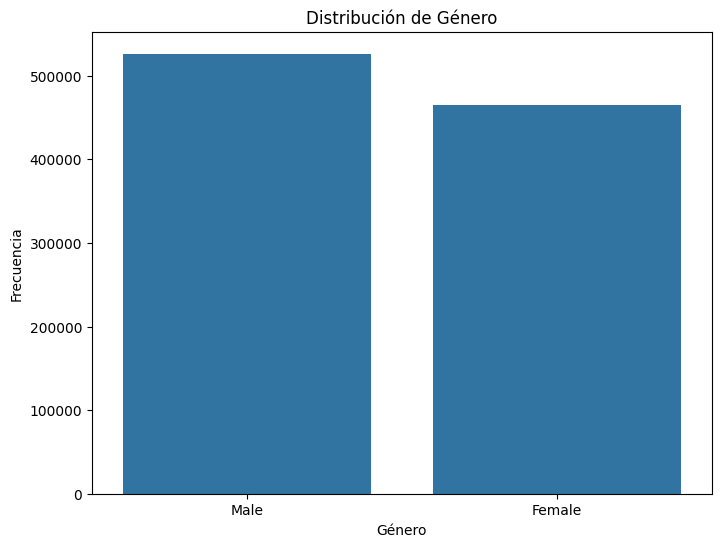

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sex')
plt.title('Distribución de Género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.show()

Podemos observar que nuestro dataset contiene al rededor de 60000 casos más de hombres que de mujeres. Puede ser interesante analizar como es el comportamiento de las otras variables respecto del género.

## Edad

Dado que es un tipo de variable numerica decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos. Los histogramas son una herramienta gráfica que nos ayudan a comprender la distribución de datos numéricos, revelando patrones, concentraciones y tendencias. Esta representación visual facilita la identificación de posibles sesgos, la presencia de outliers y proporciona una visión más detallada de la variabilidad de la variable.

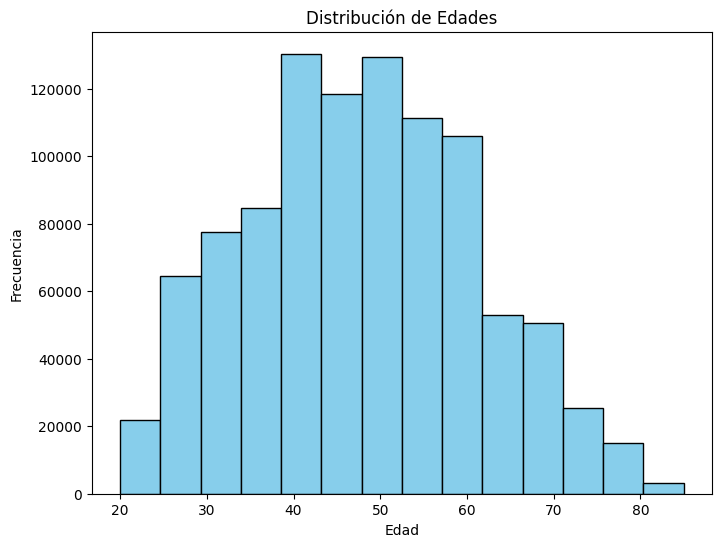

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['age'],edgecolor = "black", color='skyblue', bins=14)
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

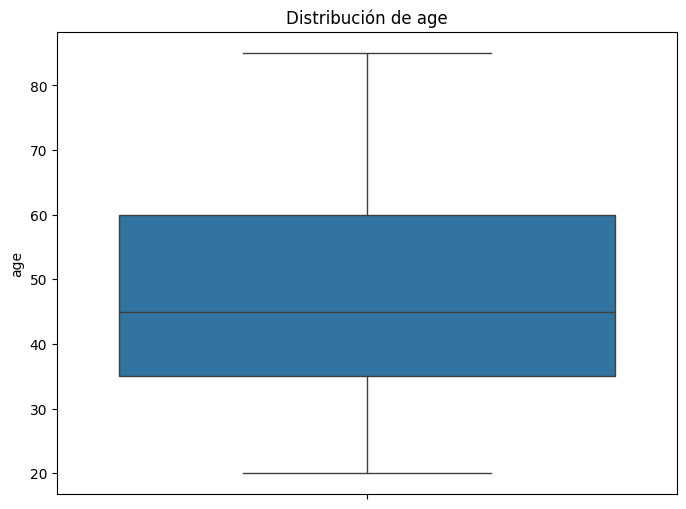

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='age')
plt.title('Distribución de age')
plt.show()

Veamos un gráfico en el que podamos ver mejor la distribución de esta variable.

<Axes: xlabel='Height', ylabel='Density'>

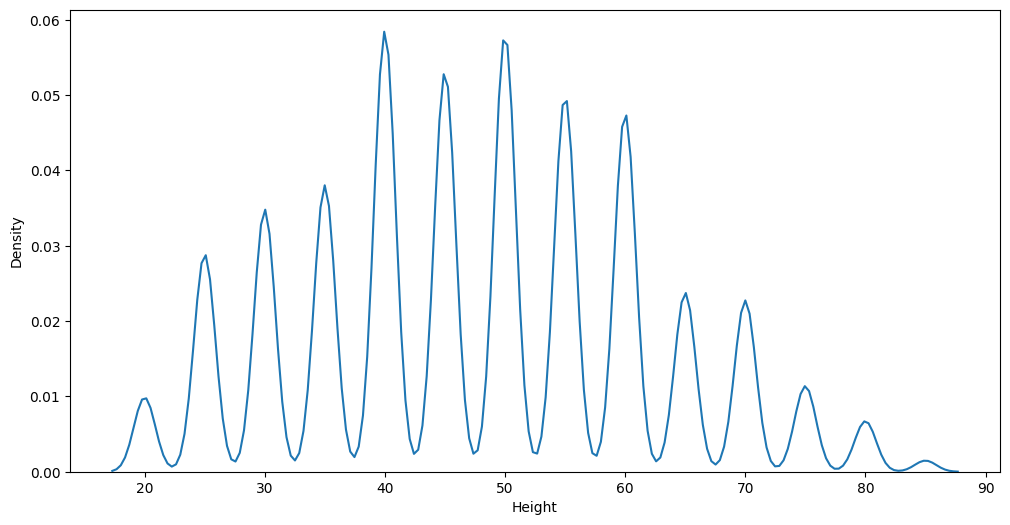

In [ ]:
plt.figure(figsize=(12,6))
plt.xlabel("Height")
plt.ylabel("Density")
sns.kdeplot(df.age)

En el gráfico de arriba se observa la distribución de densidad de la variable **Edad**. recordemos que los valores de esta variable se encuentran redondeados hacia arriba en 5 años lo que se evidencia en los picos del gráfico.
A su vez vemos que la tendencia general de los datos pareciera tener una distribución normal.

## Height

Dado que es un tipo de **variable numérica** decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

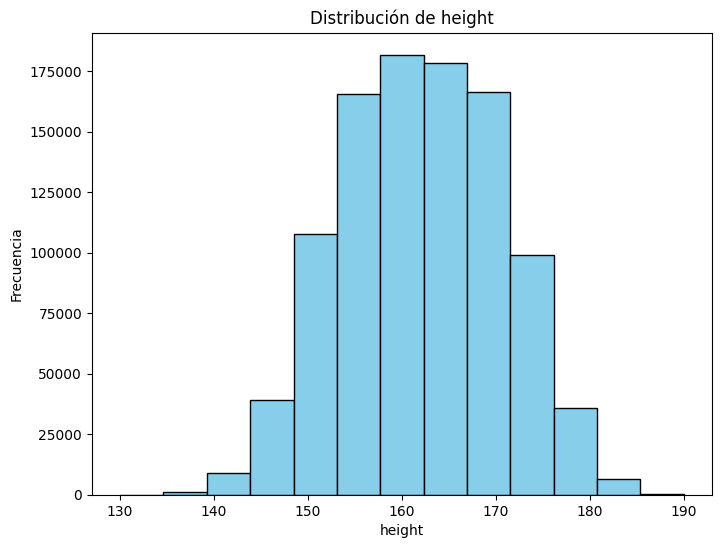

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['height'],edgecolor = "black", bins=13, color='skyblue')
plt.title('Distribución de height')
plt.xlabel('height')
plt.ylabel('Frecuencia')
plt.show()

Se observa una distribución normal donde los valores con mayor frecuencia se encuentran alrededor de 160.

Para complementar el histograma me parecio interesante agregar el siguiente gráfico de caja

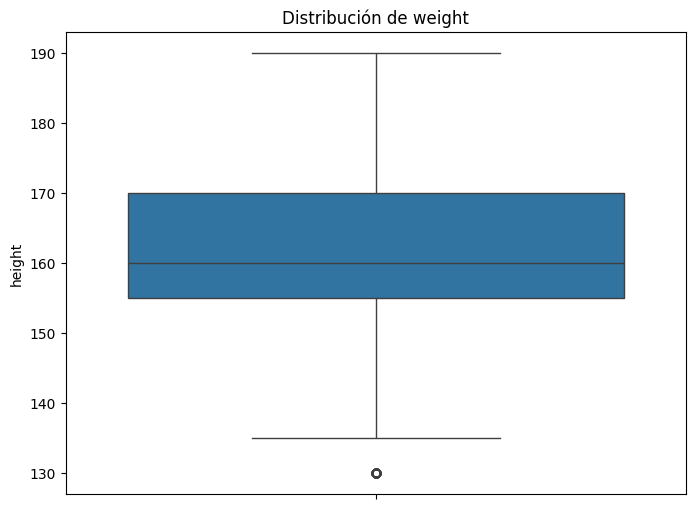

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='height')
plt.title('Distribución de weight')
plt.show()

Pareciera haber valores atípicos para lo cual vamos a calcular el IQR para un valor de 1.5

In [ ]:
df[df['height']<132.5]

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
29250,Female,80,130,35,71.0,0.1,0.1,1.0,2.0,135.0,...,94.0,84.0,12.6,1.0,0.6,35.0,28.0,12.0,1.0,N
40943,Female,80,130,30,87.0,0.4,0.4,1.0,1.0,159.0,...,96.0,119.0,11.5,1.0,0.9,30.0,19.0,17.0,1.0,N
42173,Female,85,130,35,72.0,0.1,0.3,1.0,1.0,120.0,...,77.0,69.0,10.5,1.0,0.5,26.0,12.0,46.0,1.0,N
44767,Female,75,130,40,88.0,0.3,0.5,1.0,1.0,135.0,...,150.0,32.0,12.7,1.0,0.7,24.0,15.0,15.0,1.0,N
61199,Female,80,130,40,80.0,0.3,0.6,1.0,1.0,110.0,...,108.0,136.0,12.9,1.0,0.9,22.0,14.0,22.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874945,Female,80,130,35,78.0,0.2,0.2,1.0,1.0,108.0,...,90.0,66.0,12.9,1.0,0.6,21.0,12.0,20.0,1.0,N
877028,Female,80,130,40,81.0,0.5,0.1,1.0,1.0,130.0,...,138.0,245.0,11.6,1.0,0.9,29.0,23.0,26.0,1.0,N
902184,Female,80,130,40,83.0,0.7,0.7,2.0,2.0,130.0,...,113.0,184.0,11.7,1.0,1.2,23.0,11.0,25.0,1.0,N
928214,Female,75,130,30,76.0,0.5,0.6,2.0,1.0,130.0,...,100.0,152.0,12.5,1.0,0.6,24.0,17.0,30.0,1.0,Y


In [ ]:
# Veamos iqr
iqr = df['height'].quantile(0.75) - df['height'].quantile(0.25) #3er cuartil - 1er cuartil

In [ ]:
limite_superior = df['height'].quantile(0.75) + 1.5*iqr
limite_inferior = df['height'].quantile(0.25) - 1.5*iqr

In [ ]:
print(limite_superior)

192.5


In [ ]:
print(limite_inferior)

132.5


Teniendo el limite superior e inferior vamos a quitar los datos atipicos de nuestro dataframe y guardarlos en otro dataframe llamado **"outlier_height_por_iqr"**

In [ ]:
outlier_height_por_iqr = df.loc[(df['height'] > limite_superior) | (df['height']< limite_inferior)]
df = df.loc[(df['height'] <= limite_superior) & (df['height'] >= limite_inferior)]
df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [ ]:
outlier_height_por_iqr.shape

(86, 24)

Hay 86 valores que podemos considerar atípicos de acuerdo a IQR

In [ ]:
df.shape

(991234, 24)

## weight

Dado que es un tipo de **variable numérica** decidimos visualizar la distribución utilizando un histograma para llevar a cabo una exploración más profunda y precisa de los datos.

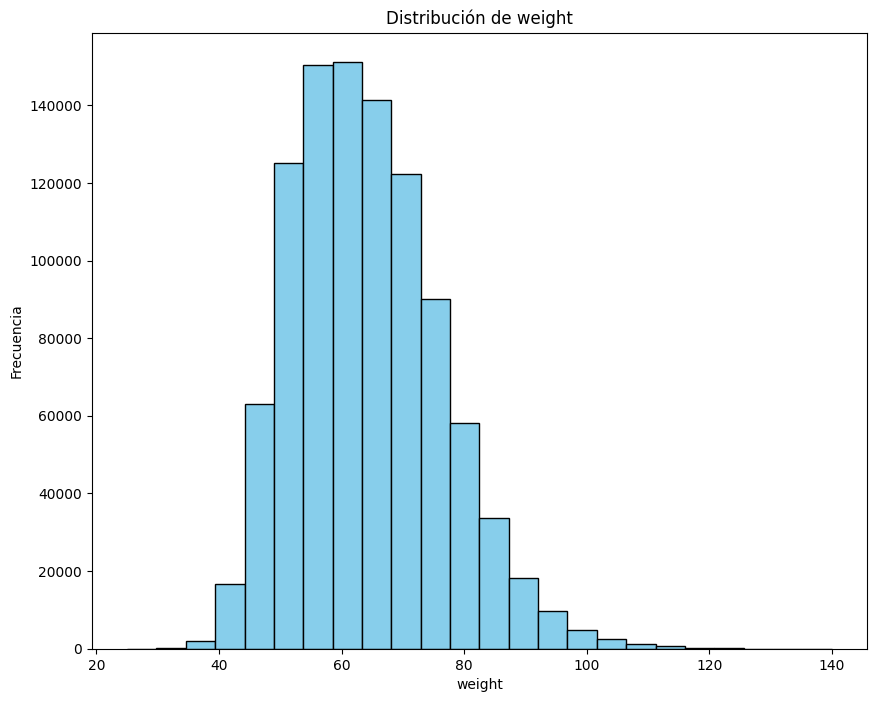

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['weight'],edgecolor = "black", bins=24, color='skyblue')
plt.title('Distribución de weight')

plt.xlabel('weight')
plt.ylabel('Frecuencia')
plt.show()

Se observa una distribución norma, hay mayor frecuencia de valores alrededor de 60.

Tambien en este caso me parecio interesante acompañar el histograma con su correspondiente diagrama de caja.

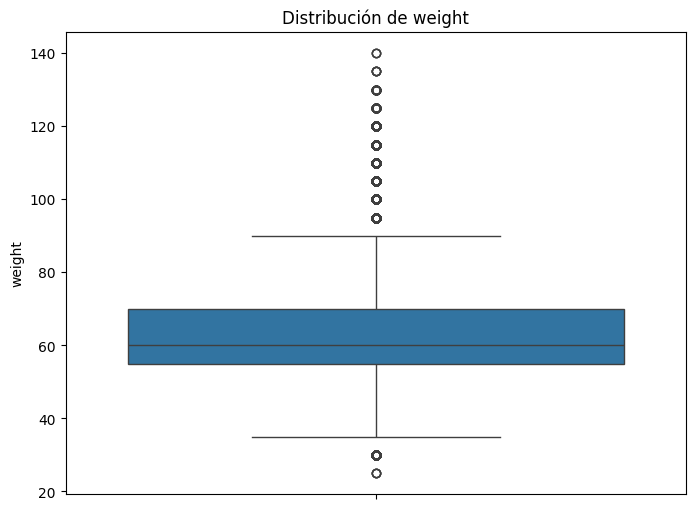

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='weight')
plt.title('Distribución de weight')
plt.show()

Vemos que tenemos outliers, la caja no esta centrada.

Calculamos el IQR para esta columna

In [ ]:
# Veamos iqr
iqr = df['weight'].quantile(0.75) - df['weight'].quantile(0.25) #3er cuartil - 1er cuartil

In [ ]:
limite_superior = df['weight'].quantile(0.75) + 1.5*iqr
limite_inferior = df['weight'].quantile(0.25) - 1.5*iqr

In [ ]:
outlier_weight_por_iqr = df.loc[(df['weight'] > limite_superior) | (df['weight'] < limite_inferior)]
df = df.loc[(df['weight'] <= limite_superior) & (df['weight'] >= limite_inferior)]
df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [ ]:
outlier_weight_por_iqr.shape

(19197, 24)

Hay aproximadamente 19000 valores outliers en esta variable

In [ ]:
df.shape

(972037, 24)

In [ ]:
df_raw.shape

(991346, 24)

## waistline: cintura

Tenemos que es una variable numerica de tipo float. Veamos su distribución con un histograma y un gráfico de caja.

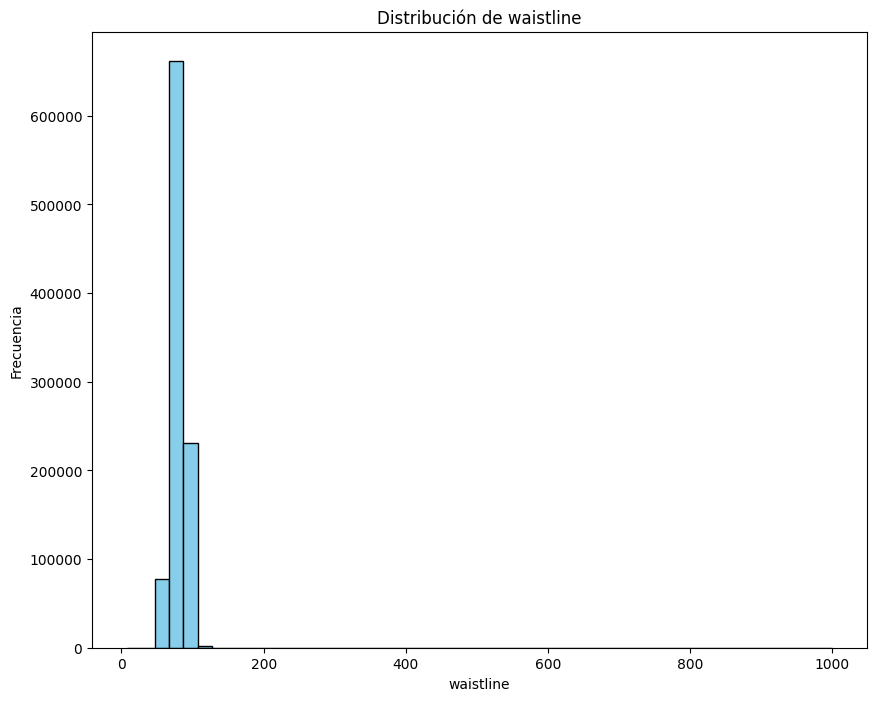

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['waistline'],edgecolor = "black", bins=50, color='skyblue')
plt.title('Distribución de waistline')

plt.xlabel('waistline')
plt.ylabel('Frecuencia')
plt.show()

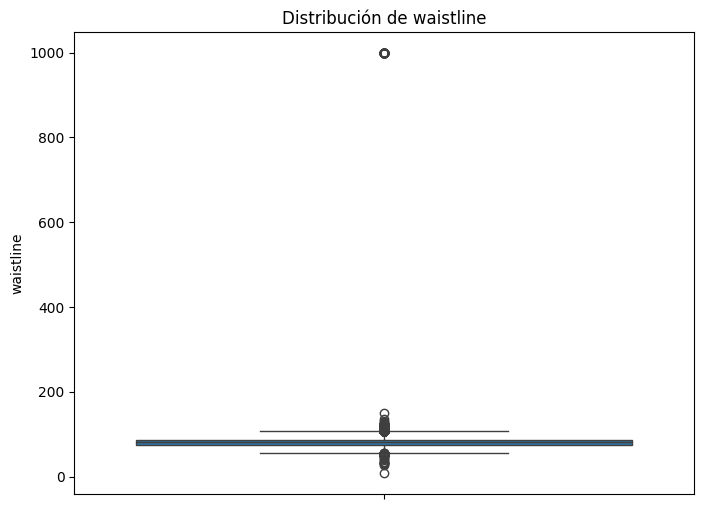

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='waistline')
plt.title('Distribución de waistline')
plt.show()

In [ ]:
# Veamos iqr
iqr = df['waistline'].quantile(0.75) - df['waistline'].quantile(0.25) #3er cuartil - 1er cuartil

In [ ]:
imite_superior = df['waistline'].quantile(0.75) + 1.5*iqr
limite_inferior = df['waistline'].quantile(0.25) - 1.5*iqr

In [ ]:
outlier_waistline_por_iqr = df.loc[(df['waistline'] > limite_superior) | (df['waistline']< limite_inferior)]
df = df.loc[(df['waistline'] <= limite_superior) & (df['waistline'] >= limite_inferior)]
df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [ ]:
outlier_waistline_por_iqr.shape

(96657, 24)

## sight_left: eyesight(left)

Dado que es un tipo de variable numerica con un amplio rango de valores decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

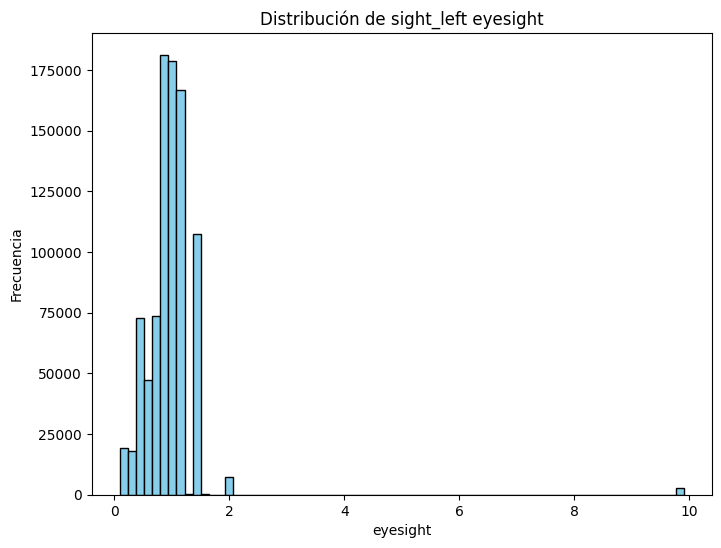

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['sight_left'],edgecolor = "black", bins=(110-40), color='skyblue')
plt.title('Distribución de sight_left eyesight')
plt.xlabel('eyesight')
plt.ylabel('Frecuencia')
plt.show()

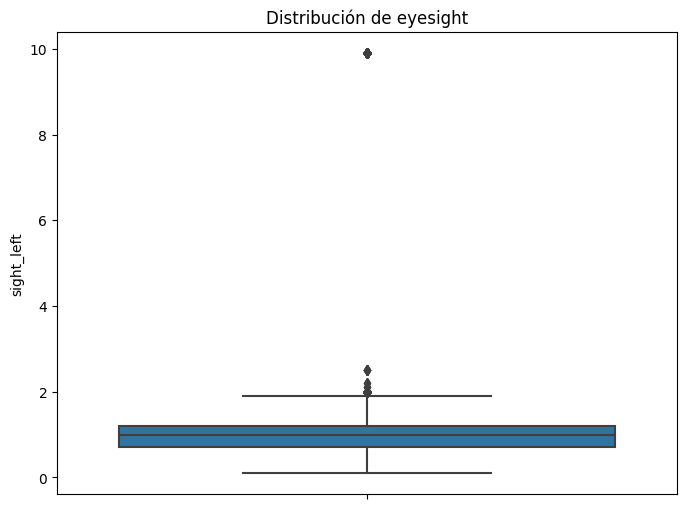

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='sight_left')
plt.title('Distribución de eyesight')
plt.show()

In [ ]:
# Veamos iqr
iqr = df['sight_left'].quantile(0.75) - df['sight_left'].quantile(0.25) #3er cuartil - 1er cuartil

In [ ]:
limite_superior = df['sight_left'].quantile(0.75) + 1.5*iqr
limite_inferior = df['sight_left'].quantile(0.25) - 1.5*iqr

In [ ]:
outlier_height_por_iqr = df[(df['sight_left'] > limite_superior) | (df['sight_left']< limite_inferior)].index
df = df.loc[(df['sight_left'] <= limite_superior) & (df['sight_left'] >= limite_inferior)]
df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [ ]:
df.shape[0]/df_raw.shape[0]*100

87.28708241118642

Vemos que esta variable toma valores desde 40 hasta 110. Aca seria interesante hacer un pequeño analisis y categorizar entre los valores normales de frecuencia cardiaca y los valores anormales. Por ejemplo, para adultos en resposo se considerean valores normales entre 60 a 100 latidos por minuto.

El histograma divide el rango de valores entre el valor minimo 40 y el valor maximo 110 en intervalos y cuenta la cantidad de valores para cada intervalo. Como podemos en este caso ver dicha cuenta es mayor que 100 para cada intervalo a excepción de 110 que hay un pico que llega hasta 250 aprox.

Notar que cada intervalo en este caso representa un unico valor.

## sight_right eyesight(right)

Como habiamos visto antes la variable "**Diabetes**" era de tipo "**int**" es decir numerica, pero vimos que el rango de valores es es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

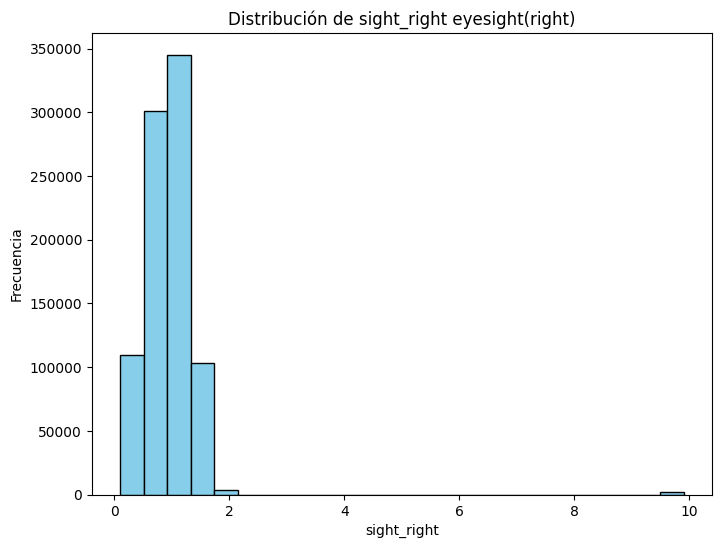

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['sight_right'],edgecolor = "black", bins=24, color='skyblue')
plt.title('Distribución de sight_right eyesight(right)')
plt.xlabel('sight_right')
plt.ylabel('Frecuencia')
plt.show()

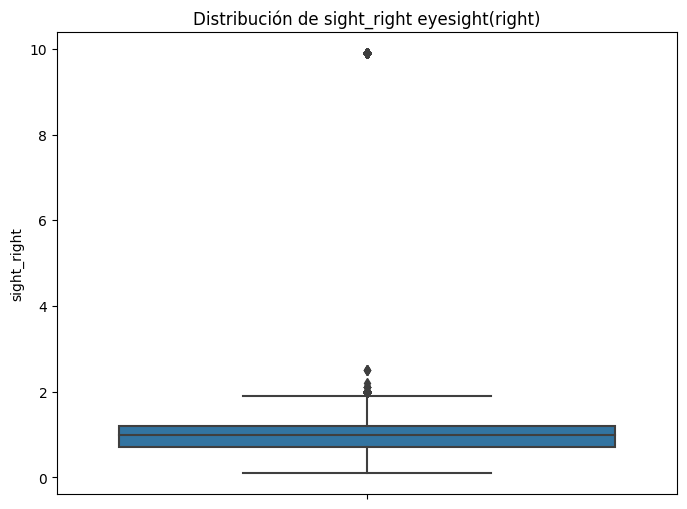

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='sight_right')
plt.title('Distribución de sight_right eyesight(right)')
plt.show()

In [ ]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# Imprimimos resultados
print('Tenemos {} columnas numericas : {}'.format(len(numerical_features), numerical_features))
print('Tenemos {} columnas categoricas : {}'.format(len(categorical_features), categorical_features))

Tenemos 22 columnas numericas : ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'SMK_stat_type_cd']
Tenemos 2 columnas categoricas : ['sex', 'DRK_YN']


In [ ]:
# Suponiendo que 'df' es tu DataFrame y 'numerical_features' es la lista de columnas numéricas
numerical = []

for column in numerical_features:
    unique_values = df[column].nunique()  # Obtener el número de valores únicos en la columna
    if unique_values > 6:
        numerical.append(column)

# 'numerical' ahora contiene las columnas que tienen más de 2 valores únicos
print(numerical)


['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']


In [ ]:
for column in numerical:
  # Veamos iqr
  iqr = df[column].quantile(0.75) - df[column].quantile(0.25) #3er cuartil - 1er cuartil
  limite_superior = df[column].quantile(0.75) + 1.5*iqr
  limite_inferior = df[column].quantile(0.25) - 1.5*iqr
  outlier_height_por_iqr = df[(df[column] > limite_superior) | (df[column]< limite_inferior)].index
  df = df.loc[(df[column] <= limite_superior) & (df[column] >= limite_inferior)]

df


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
5,Male,50,165,55,75.0,1.2,1.5,1.0,1.0,142.0,...,95.0,232.0,13.8,3.0,0.8,29.0,40.0,37.0,3.0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991340,Female,50,150,50,72.6,1.0,1.0,1.0,1.0,116.0,...,105.0,125.0,15.2,1.0,0.8,28.0,26.0,29.0,1.0,N
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y


In [ ]:
limite_superior = df['height'].quantile(0.75) + 1.5*iqr
limite_inferior = df['height'].quantile(0.25) - 1.5*iqr

In [ ]:
outlier_height_por_iqr = df[(df['height'] > limite_superior) | (df['height']< limite_inferior)].index
df = df.loc[(df['height'] <= limite_superior) & (df['height'] >= limite_inferior)]
df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
5,Male,50,165,55,75.0,1.2,1.5,1.0,1.0,142.0,...,95.0,232.0,13.8,3.0,0.8,29.0,40.0,37.0,3.0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991340,Female,50,150,50,72.6,1.0,1.0,1.0,1.0,116.0,...,105.0,125.0,15.2,1.0,0.8,28.0,26.0,29.0,1.0,N
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y


Vemos que nuestro dataset posee casi el doble de casos o personas con diabetes que sin diabetes.

## hear_left hearing left, 1(normal), 2(abnormal)

Como habiamos visto antes la variable "Family History" era de tipo "**int**" es decir numerica, pero vimos que el rango de valores es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

In [ ]:
df['hear_left'].value_counts()

1.0    569388
2.0     16679
Name: hear_left, dtype: int64

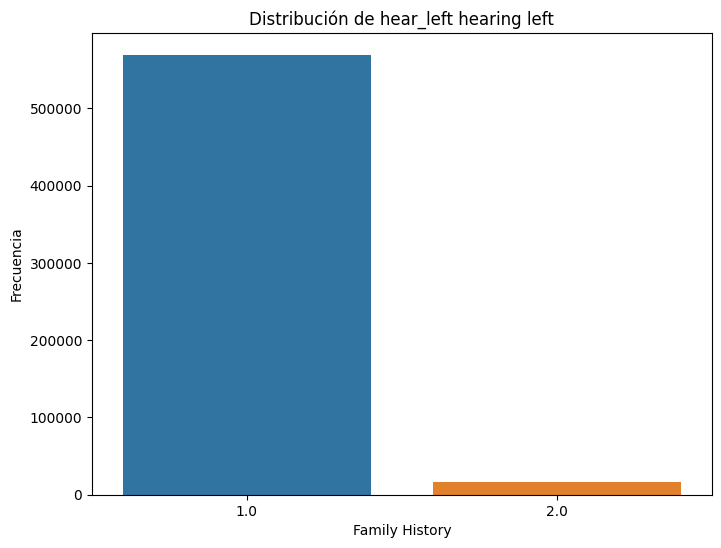

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='hear_left')
plt.title('Distribución de hear_left hearing left')
plt.xlabel('Family History')
plt.ylabel('Frecuencia')
plt.show()

Vemos que nuestro dataset tiene practicamente la misma cantidad de personas con Antecedentes familiares que sin antecendetes familiares.

##hear_right hearing right, 1(normal), 2(abnormal)

Como habiamos visto antes la variable "**Smoking**" era de tipo "**int**" es decir numerica, pero vimos que el rango de valores es es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

In [ ]:
df['hear_right'].value_counts()

1.0    569893
2.0     16174
Name: hear_right, dtype: int64

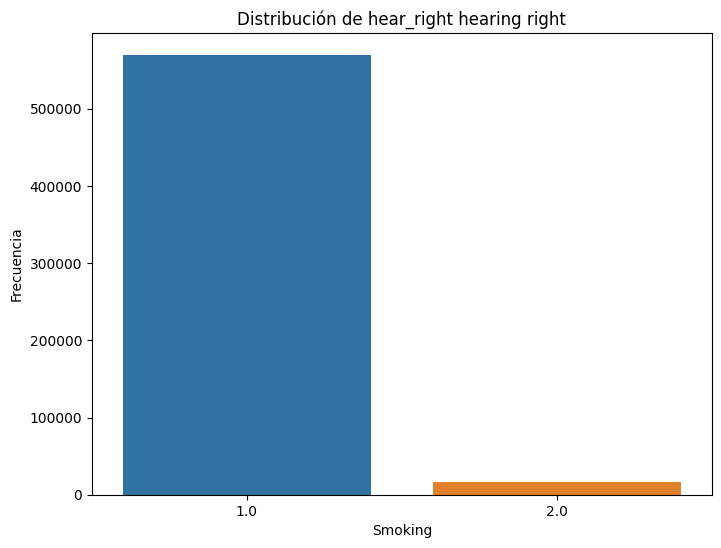

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='hear_right')
plt.title('Distribución de hear_right hearing right')
plt.xlabel('Smoking')
plt.ylabel('Frecuencia')
plt.show()

Vemos un predominio en casos de fumadores que de no fumadores, casi 9 veces más. Esto es un sesgo muy grande en nuestros datos que se debe tener en cuenta en los futuros analisis y conclusiones.

## SBP Systolic blood pressure[mmHg]

Como habiamos visto antes la variable "Obesity" era de tipo "int" es decir numerica, pero vimos que el rango de valores es esntre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

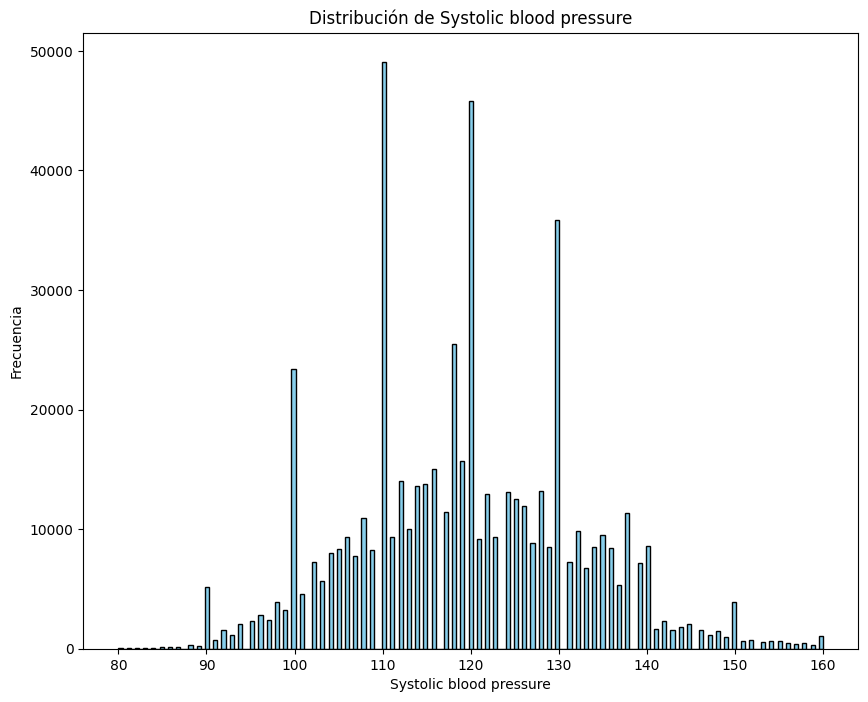

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['SBP'],edgecolor = "black", bins=171, color='skyblue')
plt.title('Distribución de Systolic blood pressure')

plt.xlabel('Systolic blood pressure')
plt.ylabel('Frecuencia')
plt.show()

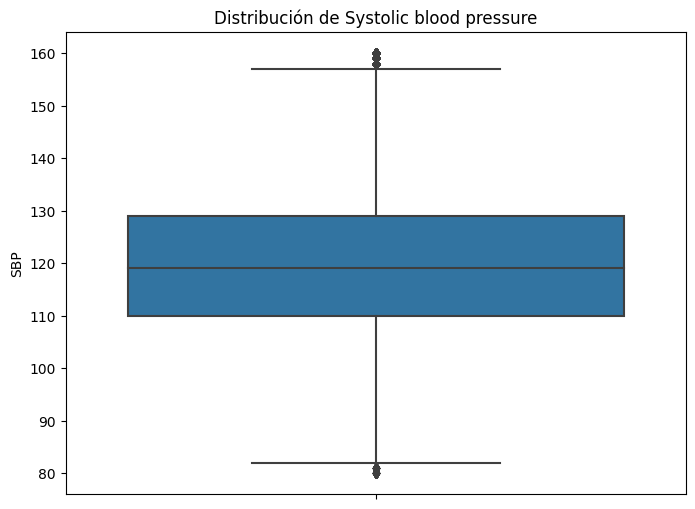

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='SBP')
plt.title('Distribución de Systolic blood pressure')
plt.show()

Vemos que en nuestro dataset hay practicamente la misma cantidad de personas con obesidad que sin obesidad

## DBP Diastolic blood pressure[mmHg]

Como habiamos visto antes la variable "Alcohol Consumption" era de tipo "int" es decir numerica, pero vimos que el rango de valores es es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

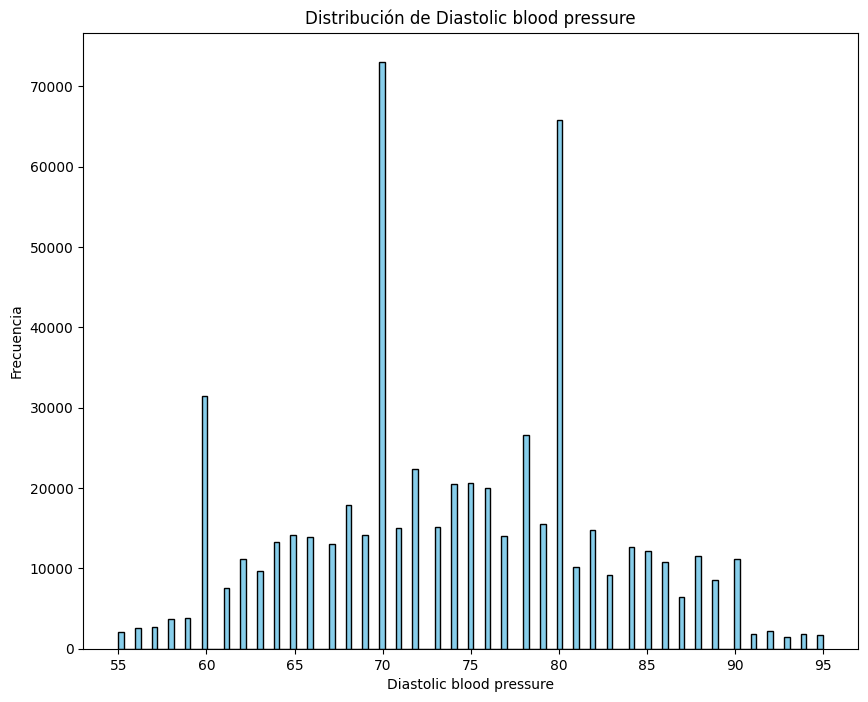

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['DBP'],edgecolor = "black", bins=127, color='skyblue')
plt.title('Distribución de Diastolic blood pressure')

plt.xlabel('Diastolic blood pressure')
plt.ylabel('Frecuencia')
plt.show()

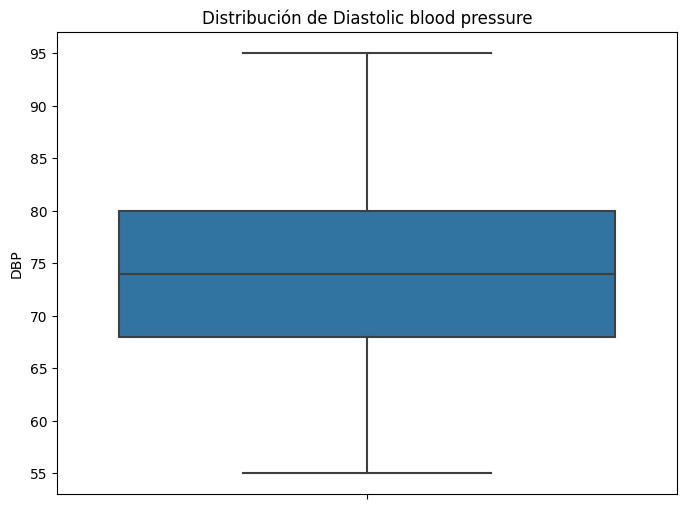

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='DBP')
plt.title('Distribución de Diastolic blood pressure')
plt.show()

Podemos observar que en nuestro dataset hay aproximadamente un 20% mas de casos con consumo de alcohol que los que no consumen alcohol.

## BLDS BLDS or FSG(fasting blood glucose)[mg/dL]

Dado que es un tipo de variable numerica decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

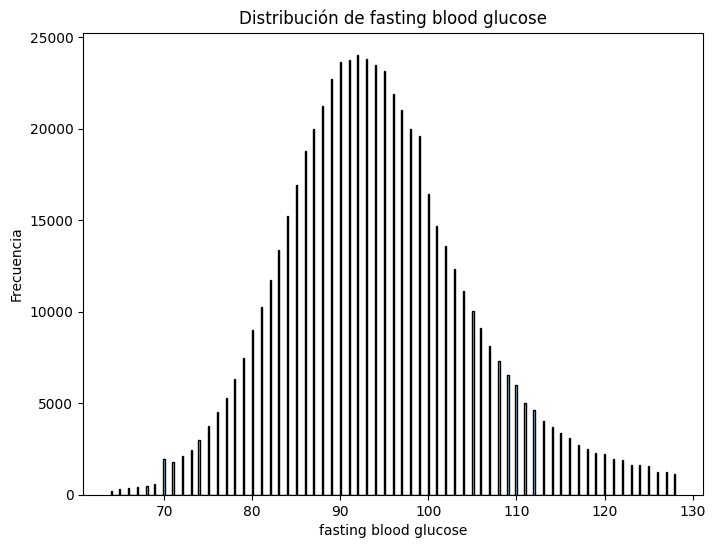

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['BLDS'],edgecolor = "black", bins=498, color='skyblue')
plt.title('Distribución de fasting blood glucose')
plt.xlabel('fasting blood glucose')
plt.ylabel('Frecuencia')
plt.show()

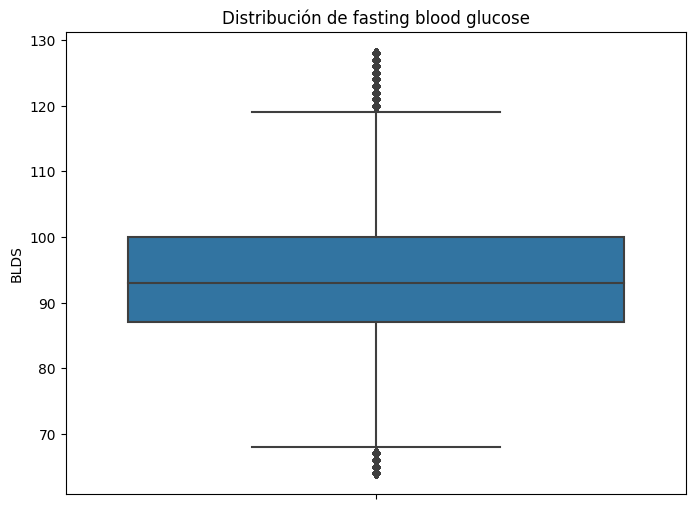

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='BLDS')
plt.title('Distribución de fasting blood glucose')
plt.show()

Vemos que las Horas de Ejercicio por semana varian desde 0 a 20 hs semanales. Simplemente observando esta variable no se puede concluir que haya una tendencia marcada en la distribución de los datos. Más bien se considera bastante uniforme superando la frecuencia de 400 para cada uno de los valores de horas de ejercicio por semana.

## tot_chole total cholesterol[mg/dL]

Como habiamos visto antes la variable "Diet" era de tipo "object" lo que puede indicar que se trata de una variable categorica. Por lo cual queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

In [ ]:
df['tot_chole'].value_counts()

184.0    7038
199.0    7006
189.0    6995
188.0    6956
187.0    6928
         ... 
102.0     126
104.0     112
100.0      71
98.0       66
99.0       58
Name: tot_chole, Length: 193, dtype: int64

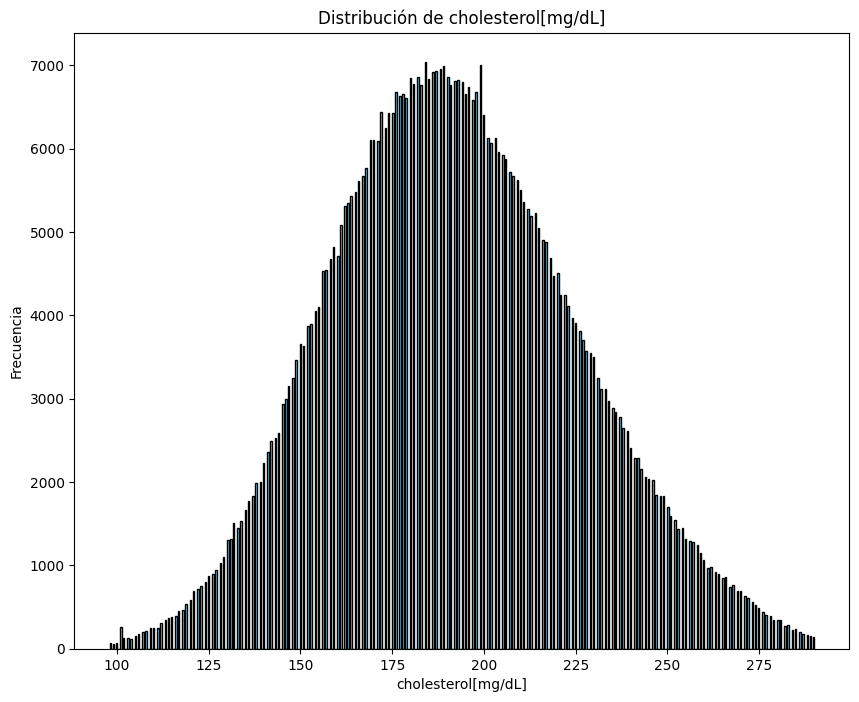

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['tot_chole'],edgecolor = "black", bins=474, color='skyblue')
plt.title('Distribución de cholesterol[mg/dL]')

plt.xlabel('cholesterol[mg/dL]')
plt.ylabel('Frecuencia')
plt.show()

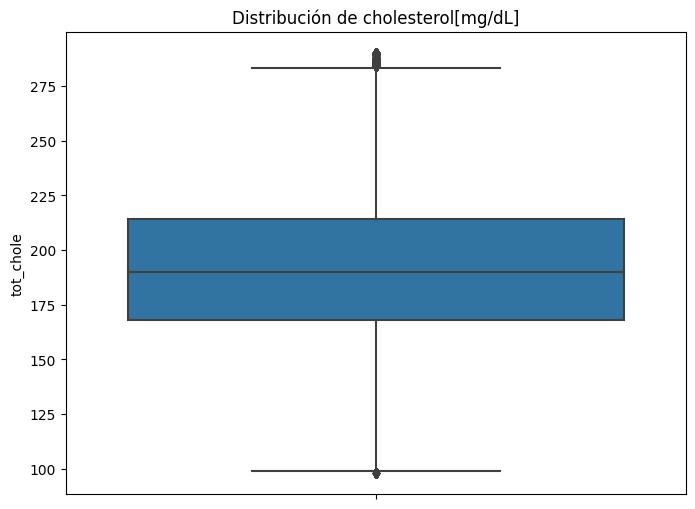

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='tot_chole')
plt.title('Distribución de cholesterol[mg/dL]')
plt.show()

Realizamos un countplot para visualizar estas cantidades

Vemos que la la cantidad de cada una de las categorias es aproximadamente la misma siendo en los 3 casos muy proximo a 2900.

## HDL_chole HDL cholesterol[mg/dL]

Como habiamos visto antes la variable "Previous Heart Problems" era de tipo "int" es decir numerica, pero vimos que el rango de valores es es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

In [ ]:
df['HDL_chole'].value_counts()

54.0    17126
53.0    17120
50.0    16990
56.0    16864
55.0    16743
        ...  
21.0       20
20.0       16
19.0       12
18.0        7
17.0        5
Name: HDL_chole, Length: 81, dtype: int64

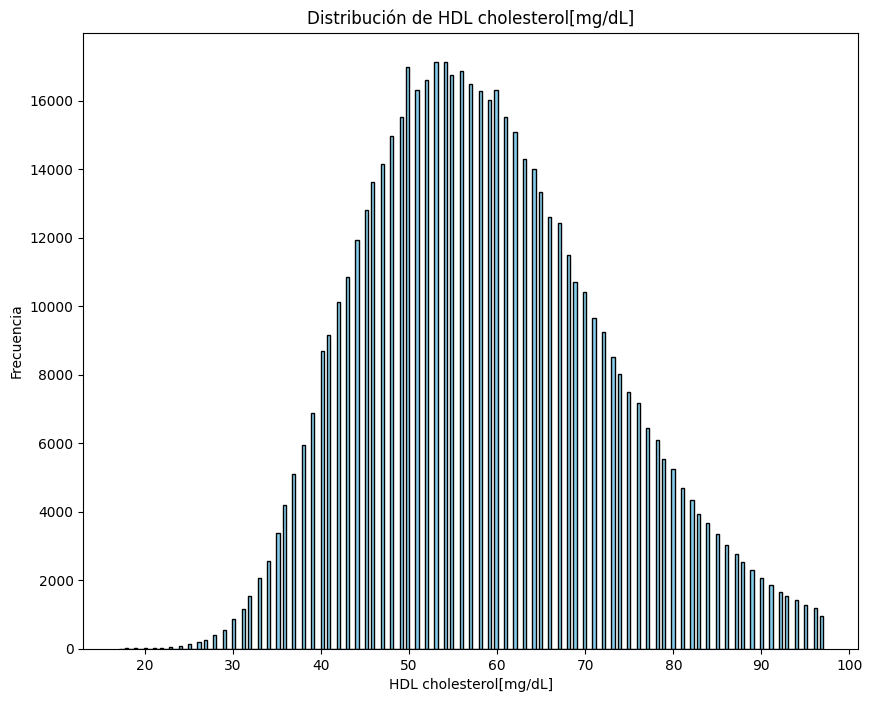

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['HDL_chole'],edgecolor = "black", bins=223, color='skyblue')
plt.title('Distribución de HDL cholesterol[mg/dL]')

plt.xlabel('HDL cholesterol[mg/dL]')
plt.ylabel('Frecuencia')
plt.show()

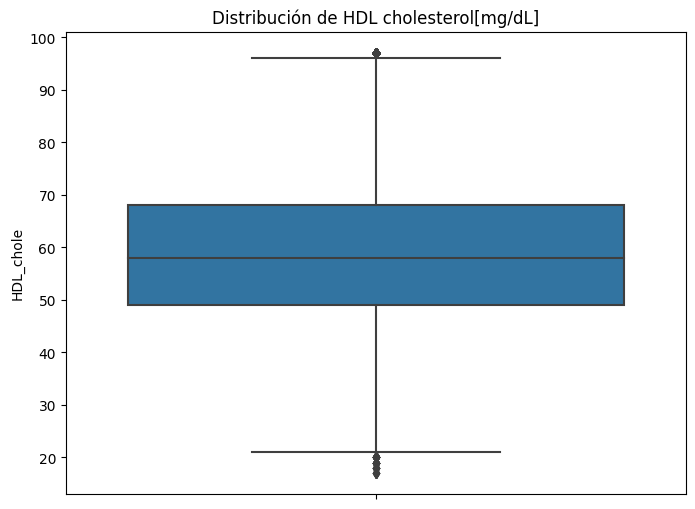

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='HDL_chole')
plt.title('Distribución de HDL cholesterol[mg/dL]')
plt.show()

Vemos que aproximadamente tenemos la misma cantidad de casos con problemas cardiacos que sin problemas cardiacos previos

## LDL_chole LDL cholesterol[mg/dL]

Como habiamos visto antes la variable "Medication Use" era de tipo "int" es decir numerica, pero vimos que el rango de valores es es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

In [ ]:
df['LDL_chole'].value_counts()

109.0    7557
107.0    7499
108.0    7469
99.0     7438
104.0    7433
         ... 
28.0       54
27.0       51
26.0       38
25.0       31
24.0       26
Name: LDL_chole, Length: 177, dtype: int64

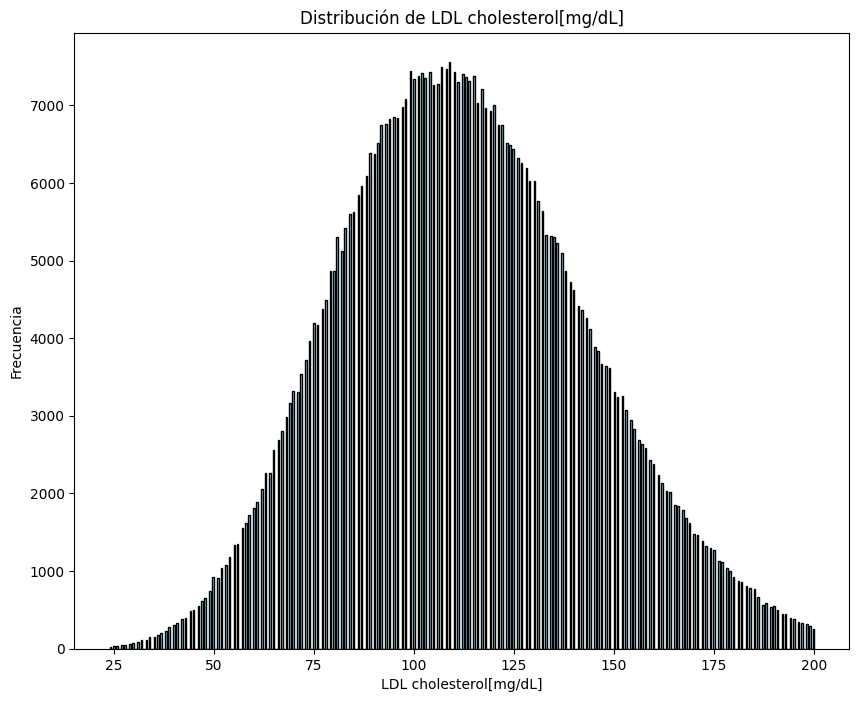

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['LDL_chole'],edgecolor = "black", bins=432, color='skyblue')
plt.title('Distribución de LDL cholesterol[mg/dL]')

plt.xlabel('LDL cholesterol[mg/dL]')
plt.ylabel('Frecuencia')
plt.show()

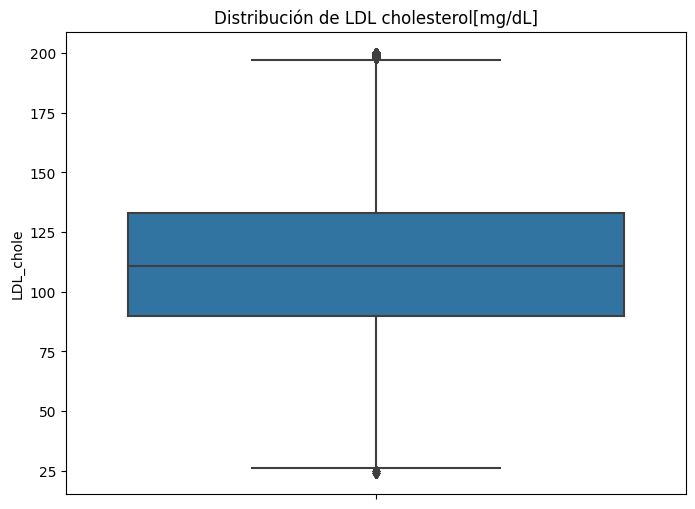

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='LDL_chole')
plt.title('Distribución de LDL cholesterol[mg/dL]')
plt.show()

Vemos que aproximadamente tenemos la misma cantidad de casos que usan medicación que casos que no usan medicación.

## triglyceride triglyceride[mg/dL]

In [ ]:
df['triglyceride'].value_counts()

66.0    6159
69.0    6147
63.0    6110
72.0    6075
65.0    6065
        ... 
5.0        2
6.0        2
4.0        1
2.0        1
3.0        1
Name: triglyceride, Length: 260, dtype: int64

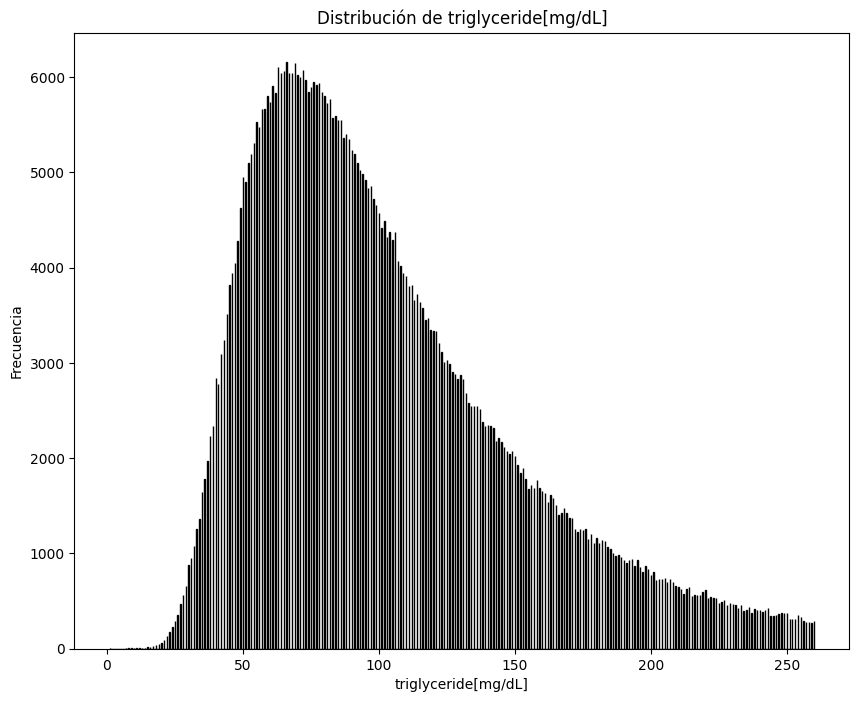

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(df['triglyceride'],edgecolor = "black", bins=1657, color='skyblue')
plt.title('Distribución de triglyceride[mg/dL]')

plt.xlabel('triglyceride[mg/dL]')
plt.ylabel('Frecuencia')
plt.show()

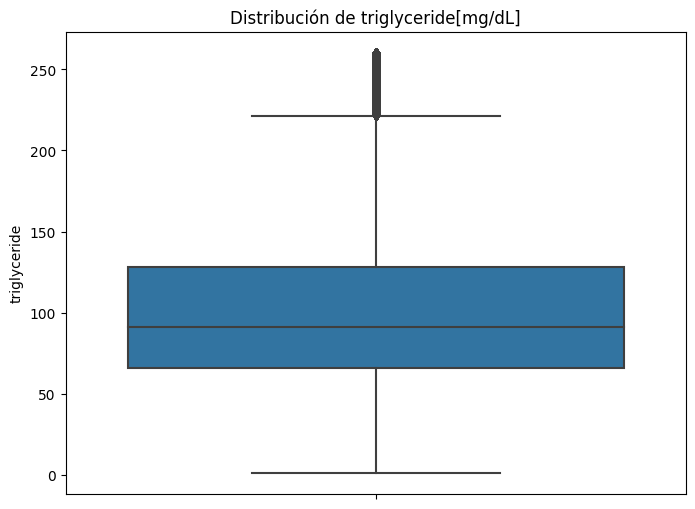

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='triglyceride')
plt.title('Distribución de triglyceride[mg/dL]')
plt.show()

## hemoglobin hemoglobin[g/dL]

In [ ]:
df['hemoglobin'].value_counts()

13.4    16551
13.3    16529
13.5    16460
13.6    16142
13.2    16049
        ...  
18.1      103
18.2       94
18.3       75
18.4       47
18.5       47
Name: hemoglobin, Length: 88, dtype: int64

Dado que es un tipo de variable numerica decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

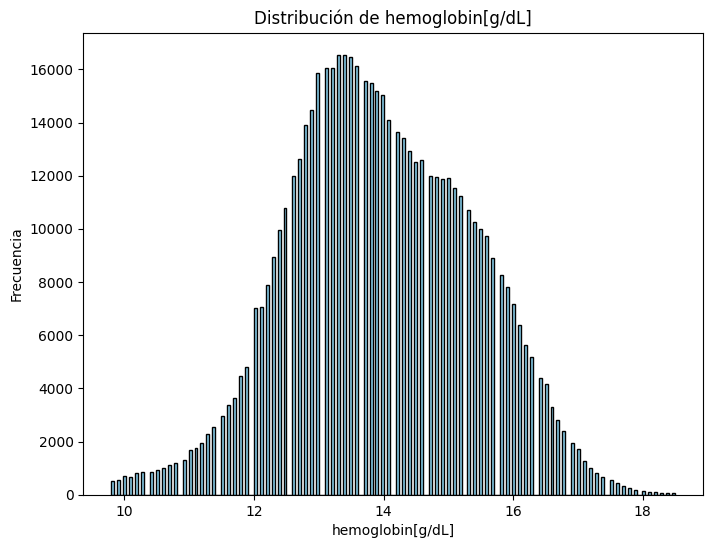

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['hemoglobin'],edgecolor = "black", bins=190, color='skyblue')
plt.title('Distribución de hemoglobin[g/dL]')
plt.xlabel('hemoglobin[g/dL]')
plt.ylabel('Frecuencia')
plt.show()

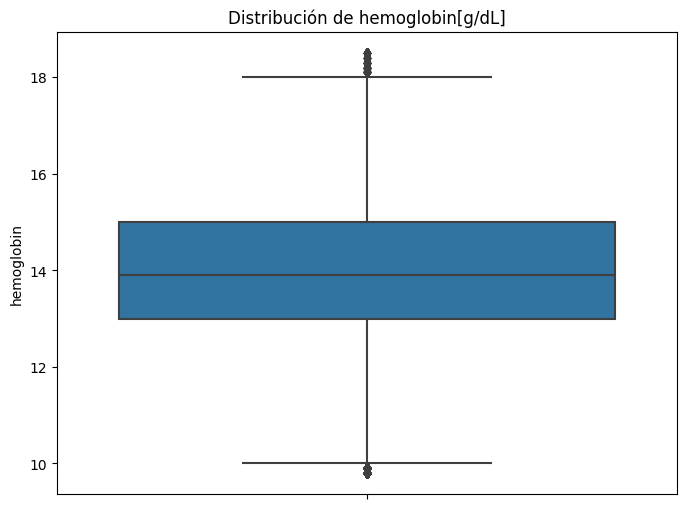

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='hemoglobin')
plt.title('Distribución de hemoglobin[g/dL]')
plt.show()

## urine_protein protein in urine, 1(-), 2(+/-), 3(+1), 4(+2), 5(+3), 6(+4)

In [ ]:
df['urine_protein'].value_counts()

1.0    560086
2.0     16436
3.0      6928
4.0      2024
5.0       489
6.0       104
Name: urine_protein, dtype: int64

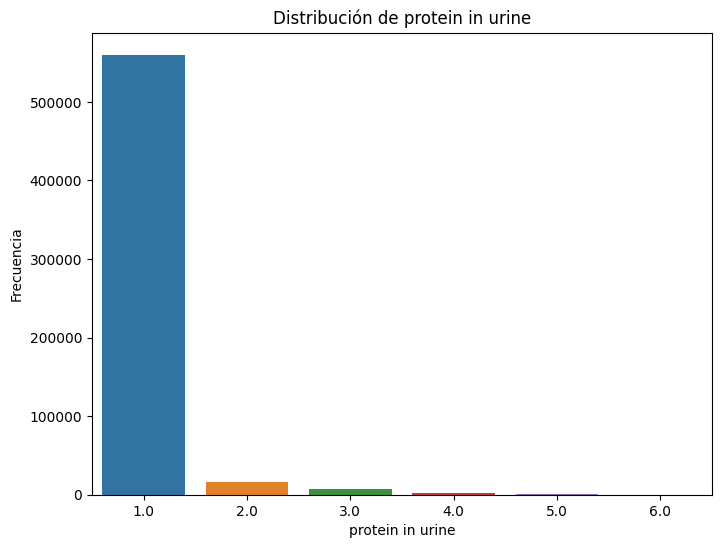

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='urine_protein')
plt.title('Distribución de protein in urine')
plt.xlabel('protein in urine')
plt.ylabel('Frecuencia')
plt.show()

Dado que es un tipo de variable numerica decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

## serum_creatinine serum(blood) creatinine[mg/dL]

In [ ]:
df['serum_creatinine'].value_counts().tail(50)

0.8    121212
0.7    111218
0.9    101151
0.6     77751
1.0     72366
1.1     42514
0.5     27655
1.2     19019
1.3      6594
0.4      3973
1.4      2269
0.3       345
Name: serum_creatinine, dtype: int64

Dado que es un tipo de variable numerica decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

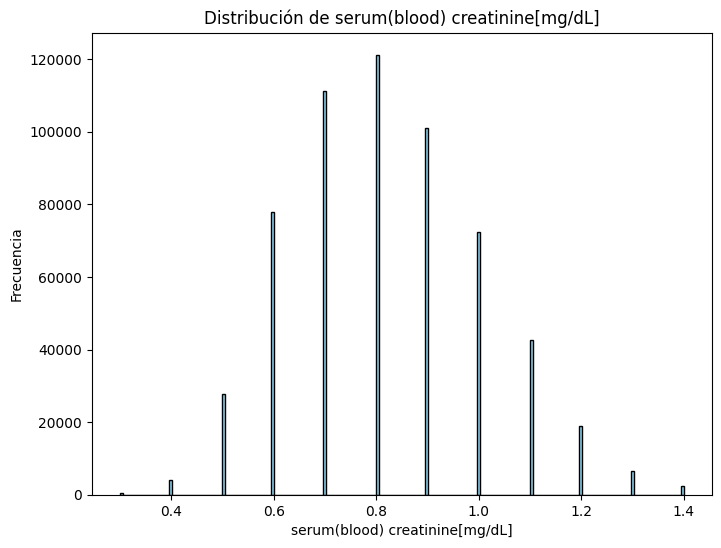

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['serum_creatinine'],edgecolor = "black", bins=183, color='skyblue')
plt.title('Distribución de serum(blood) creatinine[mg/dL]')
plt.xlabel('serum(blood) creatinine[mg/dL]')
plt.ylabel('Frecuencia')
plt.show()

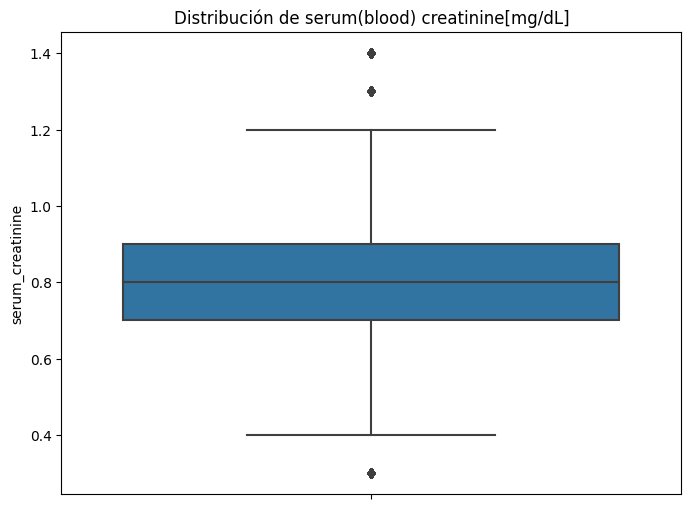

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='serum_creatinine')
plt.title('Distribución de serum(blood) creatinine[mg/dL]')
plt.show()

## SGOT_AST SGOT(Glutamate-oxaloacetate transaminase) AST(Aspartate transaminase)[IU/L]

In [ ]:
df['SGOT_AST'].value_counts()

20.0    46934
19.0    46474
21.0    44892
18.0    44243
22.0    41961
17.0    38643
23.0    37981
24.0    33668
16.0    31844
25.0    29112
15.0    24427
26.0    24377
27.0    20557
28.0    17083
14.0    16400
29.0    13873
30.0    11392
13.0     9856
31.0     9097
32.0     7445
33.0     6097
12.0     5352
34.0     4709
35.0     3986
36.0     3129
11.0     2610
37.0     2579
38.0     2070
39.0     1664
40.0     1528
10.0     1269
9.0       436
8.0       215
7.0        87
6.0        50
5.0        27
Name: SGOT_AST, dtype: int64

In [ ]:
df[df['SGOT_AST']>1000]

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN


In [ ]:
indices_a_eliminar = df[df['SGOT_AST'] > 200].index

# Eliminar las filas que cumplen la condición
df = df.drop(indices_a_eliminar)

Dado que es un tipo de variable numerica decidimos visualizar la distribución utilizando un **histograma** para llevar a cabo una exploración más profunda y precisa de los datos.

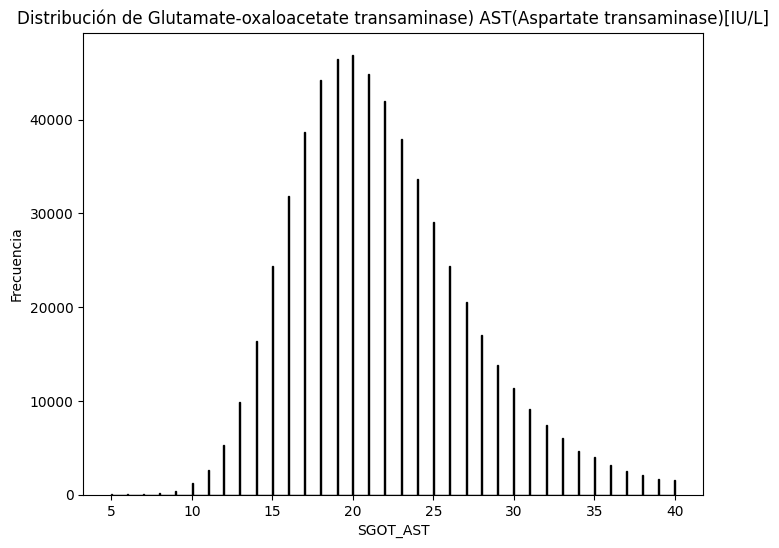

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['SGOT_AST'],edgecolor = "black", bins=568, color='skyblue')
plt.title('Distribución de Glutamate-oxaloacetate transaminase) AST(Aspartate transaminase)[IU/L]')
plt.xlabel('SGOT_AST')
plt.ylabel('Frecuencia')
plt.show()

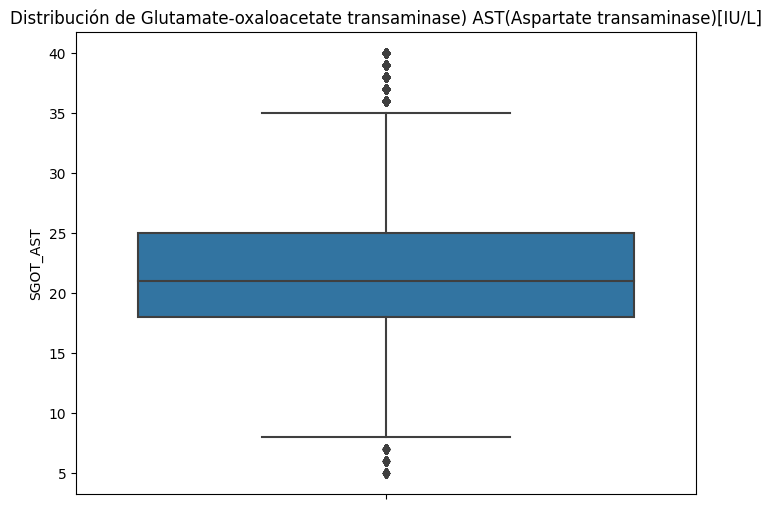

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='SGOT_AST')
plt.title('Distribución de Glutamate-oxaloacetate transaminase) AST(Aspartate transaminase)[IU/L]')
plt.show()

## SGOT_ALT ALT(Alanine transaminase)[IU/L]

In [ ]:
df['SGOT_ALT'].value_counts()

14.0    37380
15.0    37261
16.0    35943
13.0    35476
17.0    34399
12.0    33491
18.0    32232
19.0    29572
11.0    29543
20.0    26755
10.0    26390
21.0    24240
22.0    21293
23.0    18787
24.0    16710
9.0     15924
25.0    14890
26.0    12965
27.0    11101
8.0     10161
28.0    10018
29.0     9038
30.0     7955
31.0     6866
32.0     6054
7.0      5478
33.0     5364
34.0     4835
35.0     4433
36.0     3566
37.0     3300
38.0     2941
6.0      2653
39.0     2586
40.0     2365
41.0     2103
5.0      1311
4.0       468
3.0       153
2.0        50
1.0        17
Name: SGOT_ALT, dtype: int64

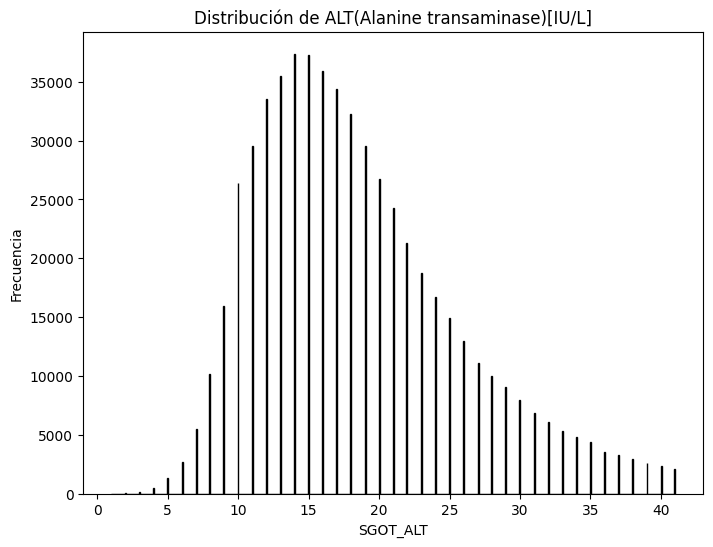

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['SGOT_ALT'],edgecolor = "black", bins=594, color='skyblue')
plt.title('Distribución de ALT(Alanine transaminase)[IU/L]')
plt.xlabel('SGOT_ALT')
plt.ylabel('Frecuencia')
plt.show()

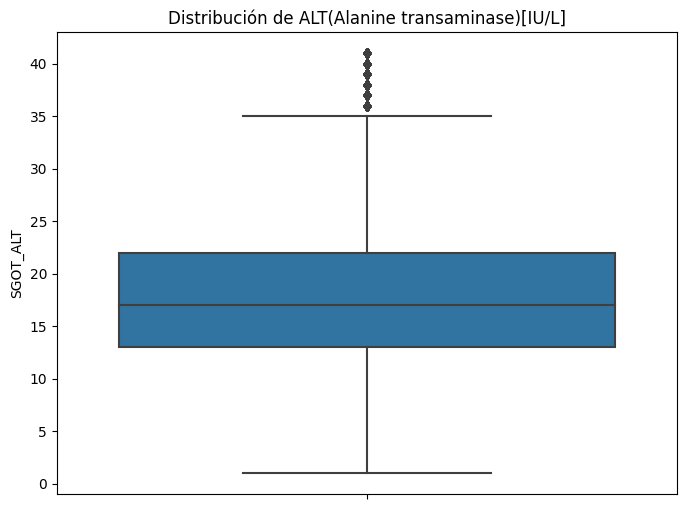

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='SGOT_ALT')
plt.title('Distribución de ALT(Alanine transaminase)[IU/L]')
plt.show()

## gamma_GTP y-glutamyl transpeptidase[IU/L]

In [ ]:
df['gamma_GTP'].value_counts()

14.0    34215
15.0    33614
13.0    33547
16.0    32071
12.0    31022
17.0    29975
18.0    27785
11.0    26882
19.0    25580
20.0    23521
10.0    21662
21.0    21398
22.0    19489
23.0    17681
24.0    16152
25.0    14828
26.0    13507
27.0    12165
9.0     12064
28.0    11277
29.0    10084
30.0     9517
31.0     8690
32.0     8171
33.0     7584
8.0      6929
34.0     6816
35.0     6297
36.0     5843
37.0     5398
38.0     5094
39.0     4623
40.0     4483
41.0     4038
42.0     3828
43.0     3492
44.0     3468
45.0     3211
7.0      2909
46.0     2892
47.0     2718
48.0     2590
49.0     2369
50.0     2314
51.0     2195
6.0      1277
5.0       503
4.0       173
3.0        91
2.0        22
1.0        13
Name: gamma_GTP, dtype: int64

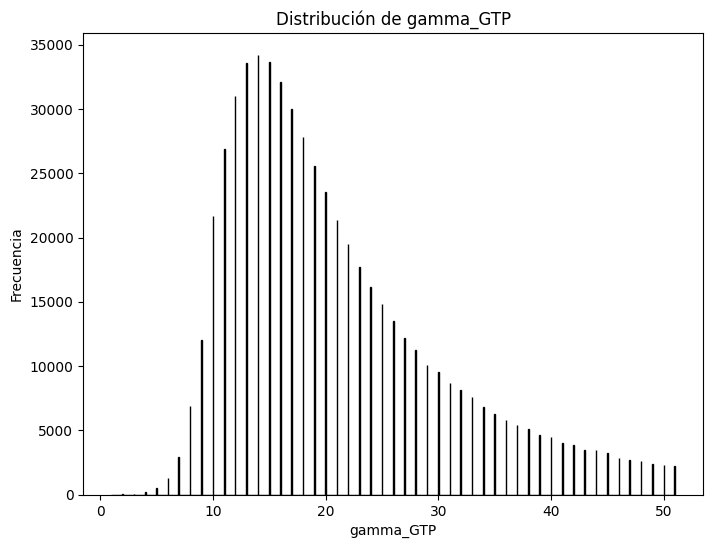

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['gamma_GTP'],edgecolor = "black", bins=940, color='skyblue')
plt.title('Distribución de gamma_GTP')
plt.xlabel('gamma_GTP')
plt.ylabel('Frecuencia')
plt.show()

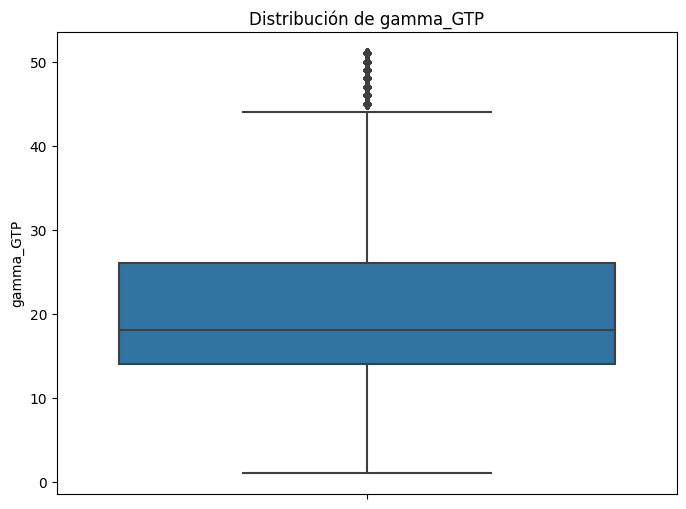

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='gamma_GTP')
plt.title('Distribución de gamma_GTP')
plt.show()

## SMK_stat_type_cd Estado fumador, 1(nunca), 2(solia fumar pero dejo), 3(todavia fuma)

In [ ]:
df['SMK_stat_type_cd'].value_counts()

1.0    407472
3.0     95606
2.0     82989
Name: SMK_stat_type_cd, dtype: int64

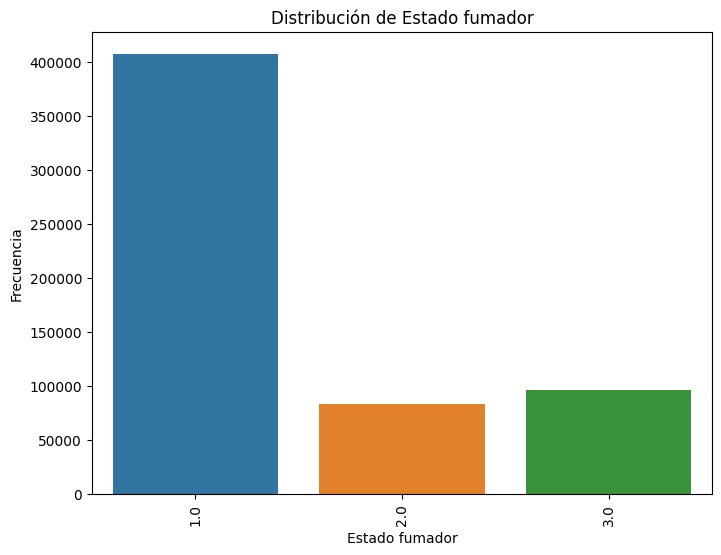

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='SMK_stat_type_cd')
plt.title('Distribución de Estado fumador')
plt.xlabel('Estado fumador')
plt.xticks(rotation=90)
plt.ylabel('Frecuencia')
plt.show()

## DRK_YN Drinker or Not

In [ ]:
df['DRK_YN'].value_counts()

N    322743
Y    263324
Name: DRK_YN, dtype: int64

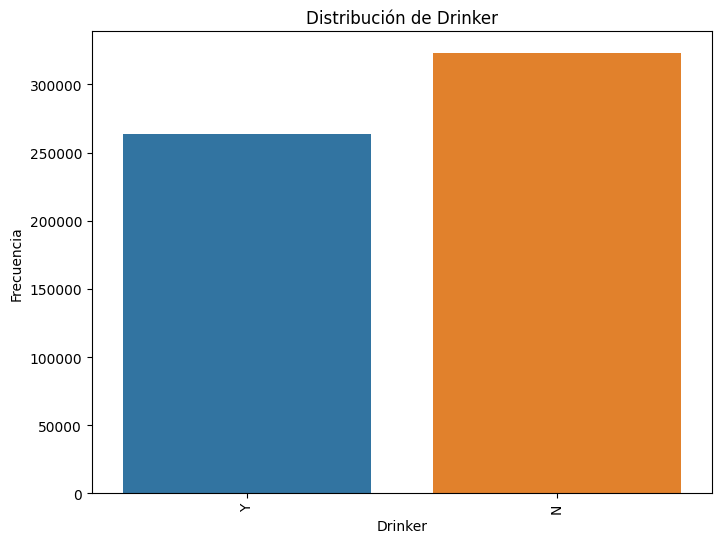

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='DRK_YN')
plt.title('Distribución de Drinker')
plt.xlabel('Drinker')
plt.xticks(rotation=90)
plt.ylabel('Frecuencia')
plt.show()

## Heart Attack Risk - Riesgo de Ataque Cardíaco

Como habiamos visto antes la variable "Heart Attack Risk" era de tipo "int" es decir numerica, pero vimos que el rango de valores es es entre 0 y 1 lo que puede indicar que unicamiente tenga esos 2 valores posibles. Para comprobarlo queremos ver los distintos posibles valores que puede tomar esta variable y frecuencia o la cuenta de esos valores. Con dicha finalidad utilizaremos la función "value_counts"

In [ ]:
# df['Heart Attack Risk'].value_counts()

Para futuros analisis consideramos que esta seria nuestra variable target por lo cual es necesario tener suficientes casos, tantos positivos como negativos. En nuestro caso vemos que tenemos casi un 40 % mas de casos negativos que de casos positivos.

# Conclusiones: Visualización univariada
Luego de llevar a cabo la visualización de cada columna y realizar un tipo de gráfico de acuerdo al tipo de variable llegamos a la conclusión de que la distribución para la mayoria de las varibles es demasiado uniforme, es decir no hay tendencias en las distribuciones. Las variables cuyos valores pueden ser 2 valores unicamente (0/1, femenino/masculino, etc.) la cuenta de cada uno siempre da muy cerca de la mitad. Para aquellas variables que son multivalor los histogramas son uniformes dando la misma cantidad para cada conjunto de valores. Todo esto nos lleva a pensar que los valores dentro de nuestro datasets fueron creados o modificados no estando apegado a la realidad de un paciente. Por lo cual continuar trabajando sobre datops artificiales nos puede llevar a conclusiones sobre una realidad erronea.

# Preguntas e hipotesis


## 1-  ¿Cómo es la distribución del colesterol para los distintos paises? ¿Hay alguna diferencia?

Primero me gustaria ver la cantidad de casos o personas que tenemos por país

Vemos que la cantidad de casos es alrededor de 450 aprox para cada país.

Ahora vamos a visualizar con un boxplot la distribución de colesterol para cada país.

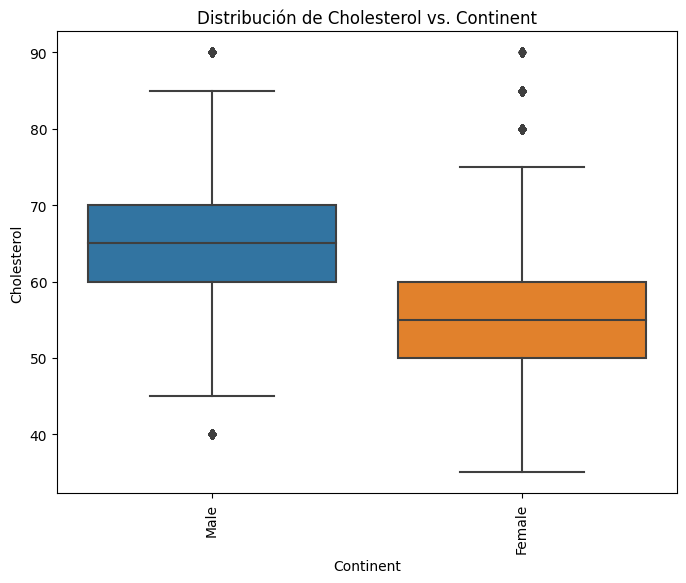

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df,x='sex', y='weight')
plt.title('Distribución de Cholesterol vs. Continent')
plt.xlabel('Continent')
plt.xticks(rotation=90)
plt.ylabel('Cholesterol')
plt.show()

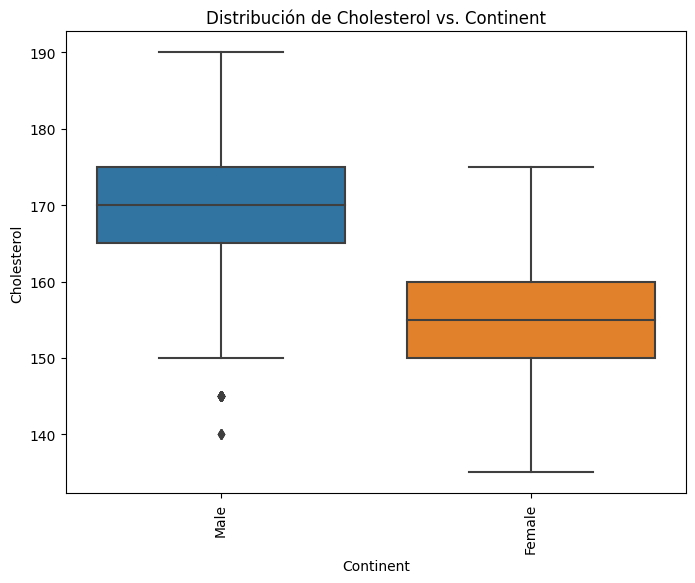

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df,x='sex', y='height')
plt.title('Distribución de Cholesterol vs. Continent')
plt.xlabel('Continent')
plt.xticks(rotation=90)
plt.ylabel('Cholesterol')
plt.show()

Podemos observar que las cajas correspondientes a:
* Argentina, United States y Colombia: los bordes superiores se encuentran superiores al resto, en el caso de Argentina particularmente tambien el borde inferior lo que quiere decir que tiene una longitud de caja mayor al resto por ende una mayor dispersión en cuanto al 50% central de los datos.

* En cuanto a los bigotes vemos que todos tienen practimante el mismo alcance y no hay datos outliers.

## 2- ¿Cómo varia la posibilidad de ataque de riesgo cardiaco de acuerdo al continente?

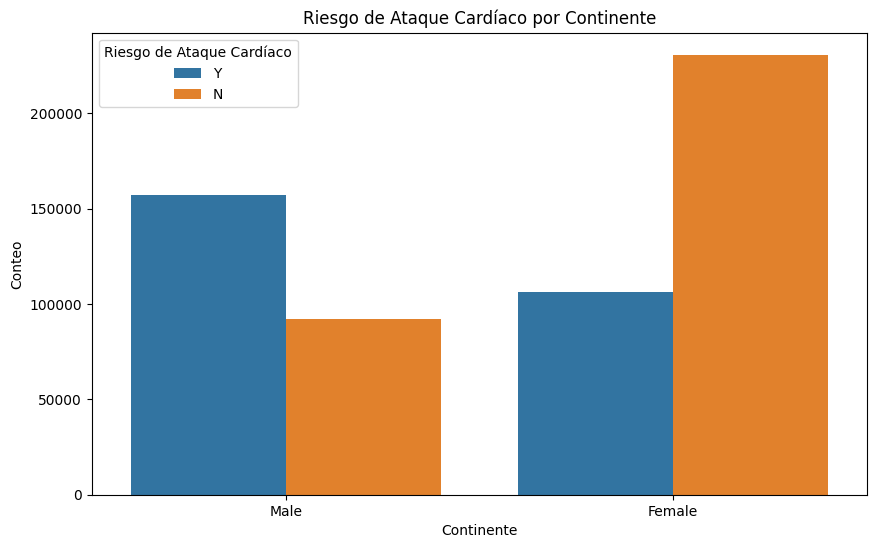

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sex', hue='DRK_YN', data=df)
plt.title('Riesgo de Ataque Cardíaco por Continente')
plt.xlabel('Continente')
plt.ylabel('Conteo')
plt.legend(title='Riesgo de Ataque Cardíaco')
plt.show()

## 3- ¿Qué relación hay entre el Colesterol y la edad y el genero? ¿Y entre el Colesterol, la edad y el riesgo de ataque cardiaco?

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cholesterol', y='Age', data=df, hue='Sex')
plt.title('Relación entre Colesterol y Edad respecto del Genero')
plt.xlabel('Colesterol')
plt.ylabel('Edad')
plt.legend(title='Sex', loc='upper right')
plt.show()

ValueError: ignored

<Figure size 1000x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cholesterol', y='Age', data=df, hue='Heart Attack Risk')
plt.title('Relación entre Colesterol y Edad respecto del Riesgo de Ataque cardiaco')
plt.xlabel('Colesterol')
plt.ylabel('Edad')
plt.legend(title='Riesgo de Ataque Cardíaco', loc='upper right')
plt.show()